# Setting Up the Data and the Model

In previous sections, we introduced:

- The neuron model → dot product + non-linearity  
- Neural networks → layers of neurons  

This extends the score function from:

$$
s = Wx
$$

to a sequence of transformations:

$$
s = W_3 f(W_2 f(W_1 x))
$$

In this section, we focus on:

- Data preprocessing  
- Weight initialization  
- Loss functions  

---

# Data Preprocessing

Assume:

$$
X \in \mathbb{R}^{N \times D}
$$

- $N$ → number of samples  
- $D$ → dimensionality  

---

## 1. Mean Subtraction (Zero-Centering)

The most common preprocessing step:

$$
X = X - \text{mean}(X)
$$

This centers the data around zero.

### Intuition

- Moves data cloud to the origin  
- Improves optimization  


In [36]:
# Mean subtraction

import numpy as np  
import matplotlib.pyplot as plt

np.random.seed(0)

X = np.random.randn(5, 3)

X -= np.mean(X, axis=0)

print(X)



[[ 0.53871831 -0.07625811  0.61946239]
 [ 1.01555916  1.39114267 -1.33655348]
 [-0.27524562 -0.62777252 -0.46249445]
 [-0.81473554 -0.33237174  1.09499791]
 [-0.46429631 -0.3547403   0.08458763]]


### For Images

- Option 1: subtract global mean  
- Option 2: subtract per-channel mean  

---

## 2. Normalization

Goal:

- Make all features have similar scale  

### Method 1: Standardization

$$
X = \frac{X}{\text{std}(X)}
$$


In [24]:
# Standard deviation normalization

X /= np.std(X, axis=0)

print(X)

[[ 0.79835039 -0.10633531  0.73104061]
 [ 1.50500186  1.93982762 -1.57729491]
 [-0.40789861 -0.87537425 -0.54579944]
 [-1.20739248 -0.46346353  1.29223009]
 [-0.68806116 -0.49465453  0.09982365]]


### Method 2: Min-Max Scaling

Scale values to range $[-1, 1]$

---

### When to Use?

- Useful when features have different units  
- Less critical for images (already in $[0, 255]$ range)  

---

## Data Preprocessing Pipeline
- Left: Original data  
- Middle: Zero-centered  
- Right: Normalized  

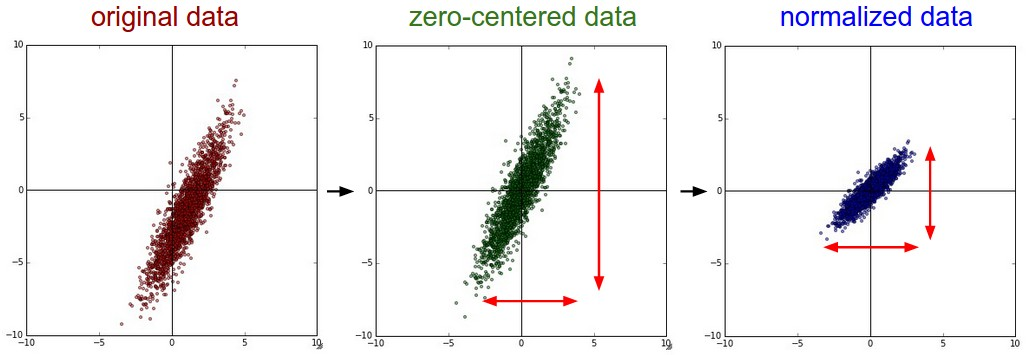

# PCA (Principal Component Analysis)

Step 1: Zero-center data  

Step 2: Compute covariance matrix:

$$
\text{cov} = \frac{X^T X}{N}
$$

## SVD Decomposition

$$
U, S, V = \text{SVD}(cov)
$$

- Columns of $U$ → eigenvectors  
- $S$ → singular values  

---

## Decorrelating the Data

$$
X_{rot} = XU
$$
## Dimensionality Reduction

Keep top $k$ components:

$$
X_{reduced} = XU_k
$$
## Whitening

Normalize each dimension:

$$
X_{white} = \frac{X_{rot}}{\sqrt{S + \epsilon}}
$$

### Warning

Whitening can:

- Amplify noise  
- Distort small-variance dimensions  

---

## PCA and Whitening Visualization
- Left: Original data  
- Middle: PCA (decorrelated)  
- Right: Whitening (scaled to identity covariance)  

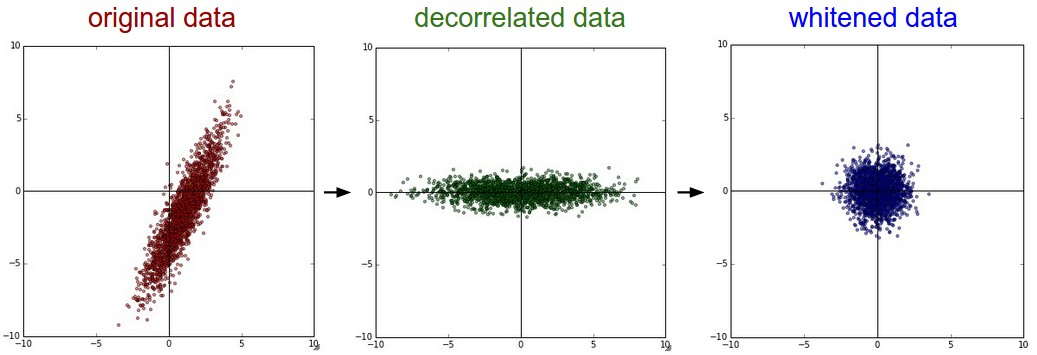


# In Practice

- PCA/Whitening → rarely used in CNNs  
- Always apply:
  - Mean subtraction  
  - Sometimes normalization  

---

# Common Pitfall ⚠️

Preprocessing must be done **ONLY on training data**.

### ❌ Wrong

- Compute mean on entire dataset  

### ✅ Correct

- Compute mean on training set  
- Apply same transformation to:
  - validation set  
  - test set  

---

## Key Takeaway

- Always zero-center your data  
- Normalize when necessary  
- Use PCA selectively  
- Avoid data leakage  

# Weight Initialization

After defining:

- Network architecture  
- Data preprocessing  

we must initialize the **learnable parameters** before training.

---

## Pitfall: All-Zero Initialization ❌

A naive idea:

$$
W = 0
$$

This is **wrong**.

### Why?

- All neurons produce the same output  
- All gradients become identical  
- All weights update in the same way  

👉 No symmetry breaking → network cannot learn  

---

## Small Random Initialization 

Instead, we initialize weights with small random values:

$$
W = 0.01 \cdot \mathcal{N}(0,1)
$$
### Intuition

- Break symmetry between neurons  
- Each neuron learns different features  
- Enables learning  

---

## Warning ⚠️

Very small weights can cause:

- Very small gradients  
- Weak gradient flow  
- Slow learning (especially in deep networks)  

---

## Variance Scaling: $1 / \sqrt{n}$

To stabilize activations, we scale weights by input size:

$$
w = \frac{\mathcal{N}(0,1)}{\sqrt{n}}
$$

Where:

- $n$ = number of input connections (fan-in)  



### Motivation

We analyze:

$$
s = \sum_i w_i x_i
$$

Variance:

$$
\text{Var}(s) = n \cdot \text{Var}(w) \cdot \text{Var}(x)
$$

To keep variance stable:

$$
\text{Var}(w) = \frac{1}{n}
$$

---

## Xavier Initialization

From Glorot et al.:

$$
\text{Var}(w) = \frac{2}{n_{in} + n_{out}}
$$

Balances:

- Forward signal  
- Backward gradients  

---

## He Initialization (Recommended for ReLU) ⭐

For ReLU networks:

$$
w = \mathcal{N}(0,1) \cdot \sqrt{\frac{2}{n}}
$$


### Why?

- ReLU discards half of activations  
- Needs larger variance to compensate  

---

## Sparse Initialization

Alternative approach:

- Most weights = 0  
- Only few connections active  
---

## Bias Initialization

Common practice:

$$
b = 0
$$
### Alternative (ReLU)

Some use:

$$
b = 0.01
$$

to ensure early activation, but:

- Not consistently better  
- Usually unnecessary  

---

## Batch Normalization

Batch Normalization stabilizes training by:

- Normalizing activations  
- Keeping mean ≈ 0 and variance ≈ 1  

### Key Idea

Instead of relying on initialization:

- Normalize activations **during training**

---

### Placement
### Benefits

- Less sensitive to initialization  
- Faster convergence  
- More stable training  

---

## Final Recommendation

- Use **ReLU activation**  
- Initialize weights with:

$$
W = \mathcal{N}(0,1) \cdot \sqrt{\frac{2}{n}}
$$

- Initialize biases to zero  
- Use Batch Normalization when possible  

- Never use zero initialization  
- Use He initialization for ReLU  
- Bias = 0 is fine  
- BatchNorm makes everything easier  

# Regularization

Regularization is used to control the capacity of Neural Networks and reduce overfitting.

Overfitting happens when a model fits the training data too closely, including noise, and fails to generalize well to unseen data.

Common regularization methods include:

- L2 regularization
- L1 regularization
- Max norm constraints
- Dropout
- Bias regularization
## L2 Regularization

L2 regularization is one of the most common forms of regularization.

For every weight $w$, we add the following penalty to the loss:

$$
\frac{1}{2}\lambda w^2
$$

For the full weight matrix $W$, this becomes:

$$
L_{reg} = \frac{1}{2}\lambda \sum W^2
$$

The factor $\frac{1}{2}$ is used because the gradient becomes simpler:

$$
\frac{\partial}{\partial w}\left(\frac{1}{2}\lambda w^2\right) = \lambda w
$$

### Intuition

L2 regularization prefers smaller and more distributed weights.

Instead of relying heavily on a few input features, the model is encouraged to use many inputs slightly.

In [39]:

np.random.seed(0)
# Example weight matrix
W = np.random.randn(5, 3)

# Regularization strength
reg = 0.1

# L2 regularization loss
l2_loss = 0.5 * reg * np.sum(W * W)

# Gradient of L2 regularization
dW_l2 = reg * W

print("L2 loss:", l2_loss)
print("L2 gradient shape:", dW_l2.shape)

L2 loss: 0.8862930895947552
L2 gradient shape: (5, 3)
